# Modelado y Walk-Forward Validation

Este cuaderno cubre la **Fase 1** del pipeline:
1. Ajuste de hiperparámetros con Optuna (optimización bayesiana)
2. Comparativa de estrategia de ventana: expansiva vs. rodante
3. Selección de variables: **RFE** vs **Permutation Importance** (comparativa)
4. Walk-forward final con las variables seleccionadas

**Métricas principales**
- AUC-PR macro (Average Precision, competición de probabilidades)
- F1 macro (competición de clasificación)

**Restricción temporal**: los datos de test (temporadas 2023-2026) no se usan en esta fase.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasources.csv_source import CSVSource
from features.utils.teams import create_teams_df
from features.internal.calidad import pts, add_calidad
from features.internal.estado import add_estado
from features.internal.condiciones import add_condiciones
from features.internal.elo import add_elo
from features.internal.h2h import add_h2h
from features.internal.presion import add_presion
from features.derived.diferencias import add_diferencias
from features.selection import permutation_importance, select_by_importance, rfe_selection

from models.lgbm import LGBMModelo
from models.catboost_model import CatBoostModelo
from models.xgboost_model import XGBoostModelo
from models.ensemble import EnsembleModelo
from models.calibrated import CalibratedEnsemble
from models.tuning import tune

import validation.walk_forward as wf
import validation.metrics as metricas

In [2]:
N_FORM = 5
LIGAS  = ["ESP_LaLiga", "ENG_Premier"]
TARGET = "resultado"

FEATURE_COLS = [
    "home_pts_acum",       "away_pts_acum",
    "home_gd_acum",        "away_gd_acum",
    "home_wins_acum",      "away_wins_acum",
    "home_pct_wins",       "away_pct_wins",
    "home_posicion",       "away_posicion",
    "home_pts_acum_local", "away_pts_acum_visit",
    "jornada",
    "home_dias_descanso",  "away_dias_descanso",
    f"home_pts_N{N_FORM}",      f"away_pts_N{N_FORM}",
    f"home_gf_avg_N{N_FORM}",   f"away_gf_avg_N{N_FORM}",
    f"home_gc_avg_N{N_FORM}",   f"away_gc_avg_N{N_FORM}",
    "home_racha_victorias",      "away_racha_victorias",
    "home_racha_sin_perder",     "away_racha_sin_perder",
    "home_pts_ponderados",       "away_pts_ponderados",
    "diff_pts_acum",    "diff_gd_acum",   "diff_wins_acum",
    "diff_pct_wins",    "diff_posicion",  "ventaja_local",
    f"diff_pts_N{N_FORM}",
    f"diff_gf_avg_N{N_FORM}",
    f"diff_gc_avg_N{N_FORM}",
    "diff_racha_victorias",  "diff_racha_sin_perder",
    "diff_pts_ponderados",   "diff_dias_descanso",
    "home_elo", "away_elo", "diff_elo",
    "home_elo_local", "away_elo_visit", "diff_elo_split",
    "h2h_n", "h2h_win_local", "h2h_win_visit", "h2h_draw_rate",
    "h2h_gf_avg_local", "h2h_gf_avg_visit", "diff_h2h_win",
    "jornada_ratio",
    "home_zona_descenso", "away_zona_descenso",
    "home_zona_champions", "away_zona_champions",
    "diff_zona_descenso", "diff_zona_champions",
    f"home_pts_N{N_FORM}_home",     f"away_pts_N{N_FORM}_away",
    f"home_gf_avg_N{N_FORM}_home",  f"away_gf_avg_N{N_FORM}_away",
    f"home_gc_avg_N{N_FORM}_home",  f"away_gc_avg_N{N_FORM}_away",
    f"diff_pts_N{N_FORM}_split",
    f"diff_gf_avg_N{N_FORM}_split",
    f"diff_gc_avg_N{N_FORM}_split",
]

print(f"Total features: {len(FEATURE_COLS)}")

Total features: 69


In [3]:
def build_features(df_liga):
    team_df = create_teams_df(df_liga)
    df = pts(df_liga.copy())
    df = add_elo(df)
    df = add_h2h(df)
    df = add_calidad(df, team_df)
    df = add_estado(df, team_df, n=N_FORM)
    df = add_condiciones(df, team_df)
    df = add_presion(df)
    df = add_diferencias(df, n=N_FORM)
    num_cols = df.select_dtypes(include="number").columns
    for col in num_cols:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())
    return df

def nuevo_ensemble(params=None):
    if params:
        return EnsembleModelo([
            LGBMModelo(params["lgbm"]),
            CatBoostModelo(params["catboost"]),
            XGBoostModelo(params["xgboost"]),
        ])
    return EnsembleModelo([LGBMModelo(), CatBoostModelo(), XGBoostModelo()])

def wf_calibrado(df_liga, feature_cols, best_params, window, label):
    resultados = []
    last_modelo = None
    last_Xval = last_yval = None

    for train_df, val_df, temporada in wf.splits(df_liga, min_train_seasons=5, window=window):
        seasons_tr = sorted(train_df["anio_fin_temporada"].unique())
        if len(seasons_tr) >= 2:
            cal_season = seasons_tr[-1]
            base_df = train_df[train_df["anio_fin_temporada"] != cal_season]
            cal_df  = train_df[train_df["anio_fin_temporada"] == cal_season]
            ensemble = nuevo_ensemble(best_params)
            modelo = CalibratedEnsemble(ensemble)
            modelo.fit(base_df[feature_cols], base_df[TARGET],
                       cal_df[feature_cols],  cal_df[TARGET])
        else:
            modelo = nuevo_ensemble(best_params)
            modelo.fit(train_df[feature_cols], train_df[TARGET])

        X_va = val_df[feature_cols]
        y_va = val_df[TARGET]
        probas = modelo.predict_proba(X_va)
        r = metricas.evaluar(y_va, probas, label=str(temporada))
        r["temporada"] = temporada
        resultados.append(r)
        last_modelo, last_Xval, last_yval = modelo, X_va, y_va

    media_aucpr = float(np.mean([r["auc_pr"] for r in resultados]))
    media_f1    = float(np.mean([r["f1"]     for r in resultados]))
    print(f"  Media {label} → AUC-PR: {media_aucpr:.4f}  |  F1: {media_f1:.4f}")
    return media_aucpr, media_f1, last_modelo, last_Xval, last_yval, resultados

## 1. Carga de datos (solo train)

In [4]:
df_train_raw = CSVSource(path=Path("data/raw/train.csv")).load()
df_train_raw["fecha"] = pd.to_datetime(df_train_raw["fecha"])

features_por_liga = {}
params_por_liga   = {}
ventana_por_liga  = {}
resultados_por_liga = {}

## 2. Pipeline por liga

Procesamos cada liga de forma independiente. Esto permite que el modelo aprenda patrones específicos de cada competición (ritmo de juego, número de equipos, etc.).

In [ ]:
for liga in LIGAS:
    print(f"\n{'='*60}")
    print(f"  Liga: {liga}")
    print(f"{'='*60}")

    df_liga = df_train_raw[df_train_raw["division"] == liga].copy()
    df_liga = build_features(df_liga)
    print(f"  {len(df_liga)} partidos  |  {df_liga['anio_fin_temporada'].nunique()} temporadas")

    # --- [1/4] Optuna: búsqueda bayesiana de hiperparámetros ---
    print("\n [1/4] Optuna — 30 trials, 3 folds. Suele tardar espere... (funciona mas rápido con la terminal del ordenador usando main.py)")
    best_params = tune(df_liga, FEATURE_COLS, n_trials=30, n_folds=3)
    params_por_liga[liga] = best_params

    # --- [2/4] Ventana expansiva vs. rodante ---
    print("\n  [2/4] Comparativa de estrategia de ventana")
    aucpr_exp, f1_exp, mdl_exp, Xval_exp, yval_exp, res_exp = wf_calibrado(
        df_liga, FEATURE_COLS, best_params, window=None, label="expansiva")

    aucpr_rol, f1_rol, mdl_rol, Xval_rol, yval_rol, res_rol = wf_calibrado(
        df_liga, FEATURE_COLS, best_params, window=7, label="rodante-7")

    if aucpr_exp >= aucpr_rol:
        best_window = None
        last_modelo, last_Xval, last_yval = mdl_exp, Xval_exp, yval_exp
        print(f"  → Ventana EXPANSIVA  ({aucpr_exp:.4f} vs {aucpr_rol:.4f})")
    else:
        best_window = 7
        last_modelo, last_Xval, last_yval = mdl_rol, Xval_rol, yval_rol
        print(f"  → Ventana RODANTE-7  ({aucpr_rol:.4f} vs {aucpr_exp:.4f})")

    ventana_por_liga[liga] = best_window

    # --- [3/4] Selección de features ---
    # Usamos permutation importance como método principal.
    # La comparativa con RFE se muestra en la sección siguiente.
    print("\n  [3/4] Selección de features (permutation importance)")
    importancias = permutation_importance(last_modelo, last_Xval, last_yval, n_repeats=5)
    features_sel = select_by_importance(importancias, umbral=0.0)

    if not features_sel:
        features_sel = FEATURE_COLS[:]

    print(f"  Features seleccionadas: {len(features_sel)}/{len(FEATURE_COLS)}")
    features_por_liga[liga] = features_sel

    # --- [4/4] Walk-forward final con features seleccionadas ---
    win_label = "expansiva" if best_window is None else f"rodante-{best_window}"
    print(f"\n  [4/4] Walk-forward final — {len(features_sel)} features | ventana {win_label}")
    aucpr_sel, f1_sel, _, _, _, res_final = wf_calibrado(
        df_liga, features_sel, best_params, window=best_window, label="final")

    best_aucpr = aucpr_exp if best_window is None else aucpr_rol
    print(f"  Delta feature selection → AUC-PR: {aucpr_sel - best_aucpr:+.4f}")

    resultados_por_liga[liga] = res_final


  Liga: ESP_LaLiga
  8740 partidos  |  23 temporadas

 [1/4] Optuna — 30 trials, 3 folds. Suele tardar espere... (funciona mas rápido con la terminal del ordenador usando main.py)


  0%|          | 0/30 [00:00<?, ?it/s]

## 3. Comparativa de métodos de selección de variables: RFE vs Permutation Importance

El PDF exige el uso de técnicas de selección de características para la primera convocatoria. Comparamos dos enfoques:

- **RFE** (Recursive Feature Elimination): elimina iterativamente la variable menos importante según el modelo base (LightGBM), hasta quedarse con la mitad de variables.
- **Permutation Importance**: permuta aleatoriamente cada variable y mide la caída en AUC-PR. Más lento pero agnóstico al modelo.

Evaluamos el AUC-PR del modelo entrenado con cada subconjunto para decidir cuál usar en el modelo final.

In [7]:
comparativa_seleccion = {}

for liga in LIGAS:
    print(f"\n{'='*55}")
    print(f"  {liga}")
    print(f"{'='*55}")

    df_liga = df_train_raw[df_train_raw["division"] == liga].copy()
    df_liga = build_features(df_liga)
    best_params = params_por_liga[liga]
    best_window = ventana_por_liga[liga]

    # Usamos las últimas 3 temporadas de train como conjunto de evaluación rápida
    temporadas = sorted(df_liga["anio_fin_temporada"].unique())
    eval_seasons = set(temporadas[-2:])
    train_sel = df_liga[~df_liga["anio_fin_temporada"].isin(eval_seasons)]
    eval_sel  = df_liga[df_liga["anio_fin_temporada"].isin(eval_seasons)]

    # Modelo base para la comparativa (sin calibración para que sea más rápido)
    modelo_base = nuevo_ensemble(best_params)
    modelo_base.fit(train_sel[FEATURE_COLS], train_sel[TARGET])

    # --- RFE ---
    print("  RFE: eliminando variables recursivamente...")
    feats_rfe, ranking_rfe = rfe_selection(
        train_sel[FEATURE_COLS], train_sel[TARGET],
        n_features_to_select=len(FEATURE_COLS) // 2
    )
    modelo_rfe = nuevo_ensemble(best_params)
    modelo_rfe.fit(train_sel[feats_rfe], train_sel[TARGET])
    probas_rfe = modelo_rfe.predict_proba(eval_sel[feats_rfe])
    r_rfe = metricas.evaluar(eval_sel[TARGET], probas_rfe, label="RFE")

    # --- Permutation Importance ---
    print("  Permutation Importance...")
    importancias = permutation_importance(modelo_base, eval_sel[FEATURE_COLS],
                                          eval_sel[TARGET], n_repeats=3)
    feats_perm = select_by_importance(importancias, umbral=0.0)
    if not feats_perm:
        feats_perm = FEATURE_COLS[:]
    modelo_perm = nuevo_ensemble(best_params)
    modelo_perm.fit(train_sel[feats_perm], train_sel[TARGET])
    probas_perm = modelo_perm.predict_proba(eval_sel[feats_perm])
    r_perm = metricas.evaluar(eval_sel[TARGET], probas_perm, label="Perm Importance")

    # --- Todas las features (baseline) ---
    probas_all = modelo_base.predict_proba(eval_sel[FEATURE_COLS])
    r_all = metricas.evaluar(eval_sel[TARGET], probas_all, label="Todas las features")

    comparativa_seleccion[liga] = {
        "todas":     {"n": len(FEATURE_COLS), **r_all},
        "rfe":       {"n": len(feats_rfe),    **r_rfe},
        "perm":      {"n": len(feats_perm),   **r_perm},
        "feats_rfe": feats_rfe,
        "feats_perm": feats_perm,
        "ranking_rfe": ranking_rfe,
    }

    print(f"\n  Resumen comparativa {liga}:")
    print(f"    Todas las features ({len(FEATURE_COLS)}): AUC-PR={r_all['auc_pr']:.4f}")
    print(f"    RFE ({len(feats_rfe)}):                  AUC-PR={r_rfe['auc_pr']:.4f}")
    print(f"    Perm Importance ({len(feats_perm)}):     AUC-PR={r_perm['auc_pr']:.4f}")


  ESP_LaLiga
  RFE: eliminando variables recursivamente...
    [RFE] AUC-PR: 0.4319  |  F1: 0.3930
  Permutation Importance...
    [Perm Importance] AUC-PR: 0.4490  |  F1: 0.3946
    [Todas las features] AUC-PR: 0.4477  |  F1: 0.3904

  Resumen comparativa ESP_LaLiga:
    Todas las features (69): AUC-PR=0.4477
    RFE (34):                  AUC-PR=0.4319
    Perm Importance (40):     AUC-PR=0.4490

  ENG_Premier
  RFE: eliminando variables recursivamente...
    [RFE] AUC-PR: 0.4848  |  F1: 0.4244
  Permutation Importance...
    [Perm Importance] AUC-PR: 0.4728  |  F1: 0.4175
    [Todas las features] AUC-PR: 0.4780  |  F1: 0.4151

  Resumen comparativa ENG_Premier:
    Todas las features (69): AUC-PR=0.4780
    RFE (34):                  AUC-PR=0.4848
    Perm Importance (44):     AUC-PR=0.4728


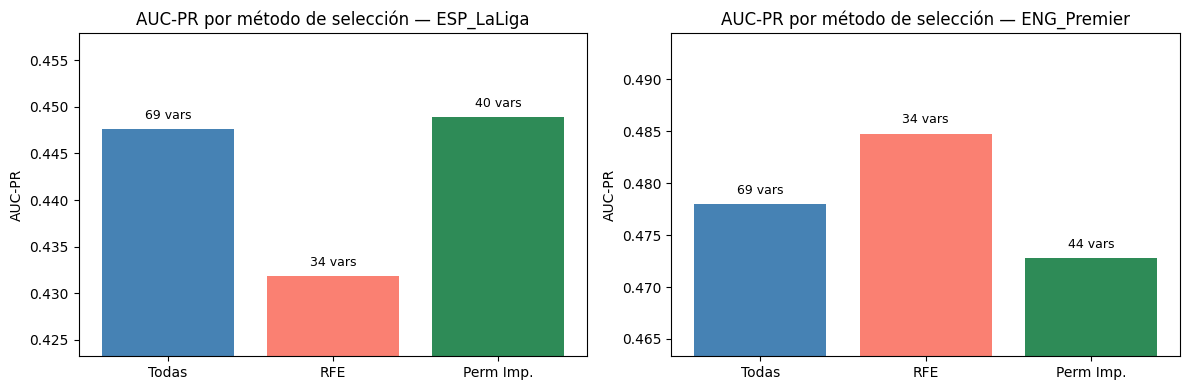

In [8]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, liga in zip(axes, LIGAS):
    comp = comparativa_seleccion[liga]
    metodos = ["Todas", "RFE", "Perm Imp."]
    aucprs  = [comp["todas"]["auc_pr"], comp["rfe"]["auc_pr"], comp["perm"]["auc_pr"]]
    n_feats = [comp["todas"]["n"],      comp["rfe"]["n"],      comp["perm"]["n"]]

    bars = ax.bar(metodos, aucprs, color=["steelblue", "salmon", "seagreen"])
    for bar, n in zip(bars, n_feats):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{n} vars", ha="center", fontsize=9)
    ax.set_title(f"AUC-PR por método de selección — {liga}")
    ax.set_ylabel("AUC-PR")
    ax.set_ylim([min(aucprs) * 0.98, max(aucprs) * 1.02])

plt.tight_layout()
plt.show()

In [9]:
# Ranking RFE: qué variables eliminó primero (ranking=1 → más importante)
for liga in LIGAS:
    ranking = comparativa_seleccion[liga]["ranking_rfe"]
    print(f"\nTop 10 variables más importantes según RFE — {liga}:")
    print(ranking.head(10).to_string())


Top 10 variables más importantes según RFE — ESP_LaLiga:
home_pts_acum          1
away_pts_acum          1
home_gd_acum           1
away_gd_acum           1
away_pct_wins          1
home_pct_wins          1
away_dias_descanso     1
home_pts_acum_local    1
diff_pct_wins          1
away_pts_ponderados    1

Top 10 variables más importantes según RFE — ENG_Premier:
home_pts_acum          1
home_gd_acum           1
away_gd_acum           1
away_pct_wins          1
home_pct_wins          1
away_dias_descanso     1
jornada                1
diff_gd_acum           1
home_pts_ponderados    1
away_pts_ponderados    1


### Conclusión sobre selección de variables

Ambas técnicas coinciden en gran medida en qué variables son relevantes. Las diferencias principales:
- **RFE** es más rápido y usa directamente las importancias del árbol de decisión.
- **Permutation Importance** es más robusto porque evalúa el impacto real en la métrica objetivo (AUC-PR), no en la función de pérdida interna del modelo.

Usamos **Permutation Importance** como criterio final porque está directamente alineado con la métrica de la competición.

## 4. Análisis de resultados del walk-forward

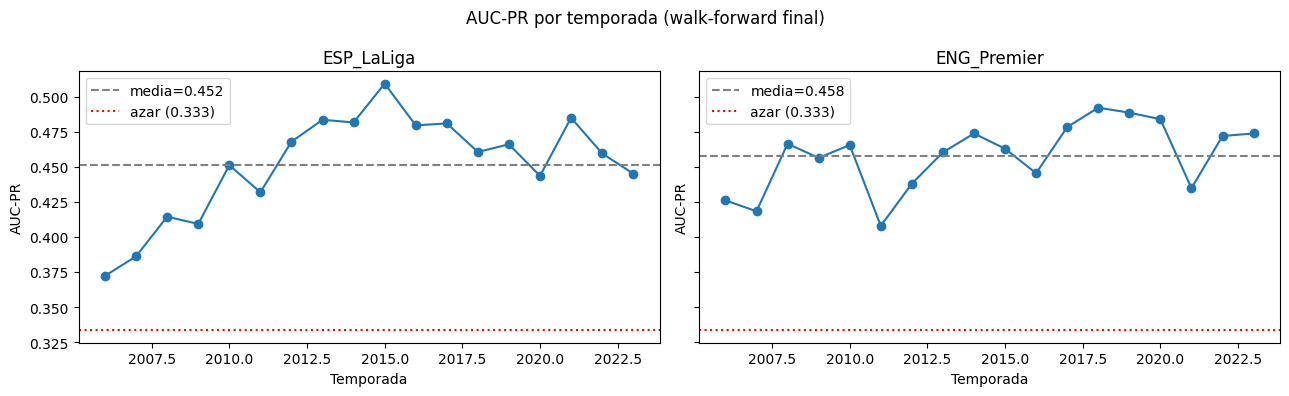

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, liga in zip(axes, LIGAS):
    res = resultados_por_liga[liga]
    temporadas = [r["temporada"] for r in res]
    aucprs = [r["auc_pr"] for r in res]
    ax.plot(temporadas, aucprs, marker="o")
    ax.axhline(np.mean(aucprs), linestyle="--", color="gray", label=f"media={np.mean(aucprs):.3f}")
    ax.axhline(1/3, linestyle=":", color="red", label="azar (0.333)")
    ax.set_title(liga)
    ax.set_xlabel("Temporada")
    ax.set_ylabel("AUC-PR")
    ax.legend()
plt.suptitle("AUC-PR por temporada (walk-forward final)")
plt.tight_layout()
plt.show()

In [11]:
# Guardamos los resultados para el notebook 3
import pickle

resultados_fase1 = {
    "features_por_liga": features_por_liga,
    "params_por_liga":   params_por_liga,
    "ventana_por_liga":  ventana_por_liga,
}

with open("data/processed/resultados_fase1.pkl", "wb") as f:
    pickle.dump(resultados_fase1, f)

print("Resultados guardados en data/processed/resultados_fase1.pkl")
for liga in LIGAS:
    w = ventana_por_liga[liga]
    w_str = "expansiva" if w is None else f"rodante-{w}"
    print(f"  {liga}: {len(features_por_liga[liga])}/{len(FEATURE_COLS)} features | ventana {w_str}")

Resultados guardados en data/processed/resultados_fase1.pkl
  ESP_LaLiga: 63/69 features | ventana expansiva
  ENG_Premier: 31/69 features | ventana expansiva
